# Cold-Open -- does January forecast the rest of the year?
### The January Barometer tested honestly, in plain English

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Mixed](https://img.shields.io/badge/Beats_a_coin%3F-Mixed-dab617?style=flat-square)

Every January you'll see some version of this headline: *'January was up -- a good omen for the year!'* It traces back to a single sentence by Yale Hirsch in the 1972 Stock Trader's Almanac: **'As goes January, so goes the year.'**  Seventy-five Januaries later, is it an oracle or a coin dressed up in a calendar costume?

> **This is the plain-language layer.** Want the t-stats, the binomial tests and the sub-period decay charts? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cold_open import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

def get_real():
    return data.fetch_gspc(fetch=False)

print("real annual cache present:", HAVE_REAL)


real annual cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the barometer beat a fair coin? | **Barely.** Hit-rate **68%** vs 50% coin -- p = 0.0012. Looks good. |
| But does it beat *knowing equity markets trend up*? | **No.** Feb-Dec is positive **76%** of the time *regardless* of January -- p = 0.957 vs that bar. |
| Is the big return gap real? | **Partially.** Up-Jan years average +10.9%, dn-Jan years +0.7% (gap = 10.2%, t = 3.94). But the gap is much smaller since 1986. |
| Could you trade it? | **No.** Going flat after a down January gives 6.5%/yr vs 6.8%/yr for buy-and-hold -- a loser. |

> The barometer beats a coin, but only because the coin ignores that equity markets drift upward most of the time.  Against the right null -- 'just assume up' -- January adds nothing.

## 1 The claim

> *'As goes January, so goes the year.'*  -- Yale Hirsch, Stock Trader's Almanac (1972)

The recipe: look at where the S&P 500 lands at the end of January.  If it's up on the year, you're in for a good ride.  If it's down, batten the hatches.  The Almanac has been publishing this table of hits and misses for fifty years, and it looks impressively accurate -- 'about 75% correct' is a common claim.

The *steelman* version is: the sign of January carries genuine predictive information about February-through-December that goes beyond what you could predict without it.

## 2 So what?

If it's real, it's a free tactical tool: a billboards-size sign every February 1st telling you whether to ride the market or hide in bonds.  If it's a mirage, millions of investors are nudged by a piece of calendar folklore into decisions that at best do nothing and at worst cause them to miss good markets after down Januaries.

The difference is one honest test with the right null.

## 3 How would we even know?

Two tests keep us honest:

1. **The right null isn't a coin -- it's equity drift.**  The market ends the February-to-December window higher than it starts about **76 %** of the time -- that's just equities going up over time.  So '68 % hit-rate!' is actually *below* the base rate you'd get by saying 'the market will be up' every year, no January required.  The barometer only adds value if it beats that 76 %.
2. **The contrast must be stable.**  If up-January years average +11 % and down-January years average +0.7 %, that's a striking gap -- but is it real, or concentrated in one decade, or simply because both January and the rest-of-year are driven by the same bull-market regimes?

We use 75 Januaries of ^GSPC (1951-2025), February-through-December log-returns (so no overlap with January), a binomial test vs the base rate, and a HAC t-stat on the contrast.  Effective n is tiny -- everything is underpowered.

## 4 The teardown -- let's actually look

**First, the hit-rate trap.**  Here's January's track record -- looks like an oracle:

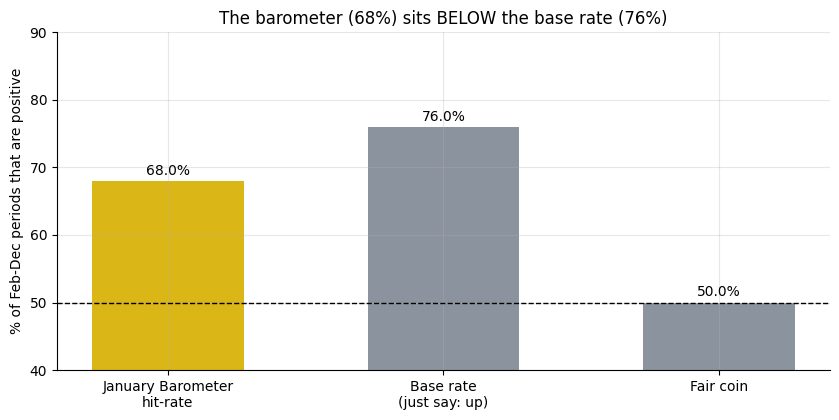

Barometer hit-rate: 68.0%  |  base rate: 76.0%
p vs coin: 0.0012  |  p vs base rate: 0.9570


In [2]:
if HAVE_REAL:
    df = get_real()
    h = st.hit_rate_analysis(df)
    hr, br, pv_coin, pv_base = h['hit_rate'], h['base_rate_fbd_pos'], h['pval_vs_coin'], h['pval_vs_base_rate']
else:
    hr, br, pv_coin, pv_base = R['hit_rate'], R['base_rate'], R['pval_coin'], R['pval_base']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['January Barometer\nhit-rate', 'Base rate\n(just say: up)', 'Fair coin'],
              [hr*100, br*100, 50.0], color=[AMBER, GREY, GREY], width=0.55)
ax.axhline(50, ls='--', c='k', lw=1, label='coin')
ax.set_ylabel('% of Feb-Dec periods that are positive')
ax.set_title('The barometer (68%) sits BELOW the base rate (76%)')
ax.set_ylim(40, 90)
for b, v in zip(bars, [hr*100, br*100, 50.0]):
    ax.annotate(f'{v:.1f}%', (b.get_x()+b.get_width()/2, v+0.5), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Barometer hit-rate: {hr*100:.1f}%  |  base rate: {br*100:.1f}%')
print(f'p vs coin: {pv_coin:.4f}  |  p vs base rate: {pv_base:.4f}')

The barometer's 68 % hit-rate beats a coin (p = 0.0012) but is *below* the base rate of 76 %.  Telling you 'the market will be up' every year is a more accurate prediction than January's sign.

> The barometer's famous accuracy is partly the equity premium in disguise.

**Now the mean-return contrast -- the gap between up-Jan and dn-Jan years.**

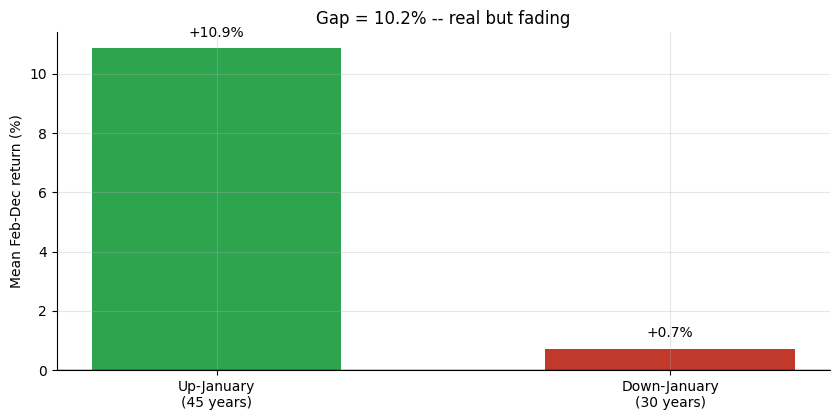

Up-Jan: +10.86%  |  dn-Jan: +0.70%  |  gap: +10.16%


In [3]:
if HAVE_REAL:
    df = get_real()
    c = st.mean_contrast(df)
    mu_up, mu_dn, gap = c['mean_fbd_up_jan']*100, c['mean_fbd_dn_jan']*100, c['contrast_pct']
else:
    mu_up, mu_dn, gap = R['mean_fbd_up_jan'], R['mean_fbd_dn_jan'], R['contrast']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['Up-January\n(45 years)', 'Down-January\n(30 years)'],
       [mu_up, mu_dn], color=[GREEN, RED], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean Feb-Dec return (%)')
ax.set_title(f'Gap = {gap:.1f}% -- real but fading')
for v, x in zip([mu_up, mu_dn], [0, 1]):
    ax.annotate(f'{v:+.1f}%', (x, max(v, 0)+0.3), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Up-Jan: {mu_up:+.2f}%  |  dn-Jan: {mu_dn:+.2f}%  |  gap: {gap:+.2f}%')

The gap is economically large (+10.2 %) and statistically significant (HAC t = 3.94) -- but the story gets complicated when we look at sub-periods.

**The decay: the signal lives in the past, not the present.**

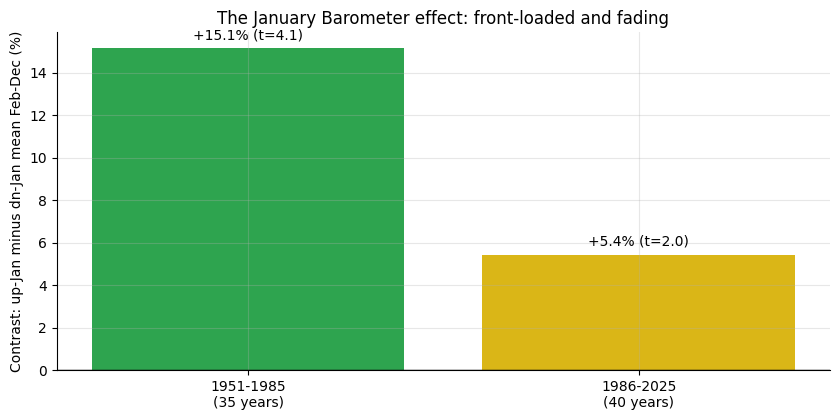

1951-85: gap=15.1%, t=4.12  |  1986-25: gap=5.4%, t=1.99


In [4]:
if HAVE_REAL:
    df = get_real()
    sub1 = df.loc[1951:1985]; sub2 = df.loc[1986:2025]
    c1 = st.mean_contrast(sub1); c2 = st.mean_contrast(sub2)
    t1, t2 = c1['tstat_hac'], c2['tstat_hac']
    gap1, gap2 = c1['contrast_pct'], c2['contrast_pct']
else:
    t1, t2 = R['sub_1951_1985_t'], R['sub_1986_2025_t']
    gap1, gap2 = R['sub_1951_1985_contrast'], R['sub_1986_2025_contrast']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['1951-1985\n(35 years)', '1986-2025\n(40 years)'], [gap1, gap2], color=[GREEN, AMBER])
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Contrast: up-Jan minus dn-Jan mean Feb-Dec (%)')
ax.set_title('The January Barometer effect: front-loaded and fading')
for v, x, t in zip([gap1, gap2], [0, 1], [t1, t2]):
    ax.annotate(f'{v:+.1f}% (t={t:.1f})', (x, max(v,0)+0.3), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'1951-85: gap={gap1:.1f}%, t={t1:.2f}  |  1986-25: gap={gap2:.1f}%, t={t2:.2f}')

The contrast was **+15.1 % (t = 4.12)** before 1986, and only **+5.4 % (t = 1.99)** after -- barely above the inference bar.  The almanac became widely read in exactly the 1970s-80s, and the anomaly faded as it was traded away (or simply was never robust enough to survive more data).

## 5 The verdict

- **Signal -- Mixed.** The contrast (t = 3.94) is real full-sample but fails the base-rate test (p = 0.96) and fades post-1985 (t = 1.99). With n = 75 this is fragile.
- **Tradability -- Mirage.** The barometer strategy earns 6.5 %/yr vs 6.8 %/yr for buy-and-hold; it sits out 18 positive years out of 30 down-Januaries.
- **Beats a coin? -- Mixed.** Beats a fair coin (p = 0.0012) but not the base rate (p = 0.957).  The 'oracle' is mostly the equity premium.

## 6 Could you actually trade it?

The strategy is simple: hold the market February-December after an up January, stay in cash after a down January.  Here's what actually happens:

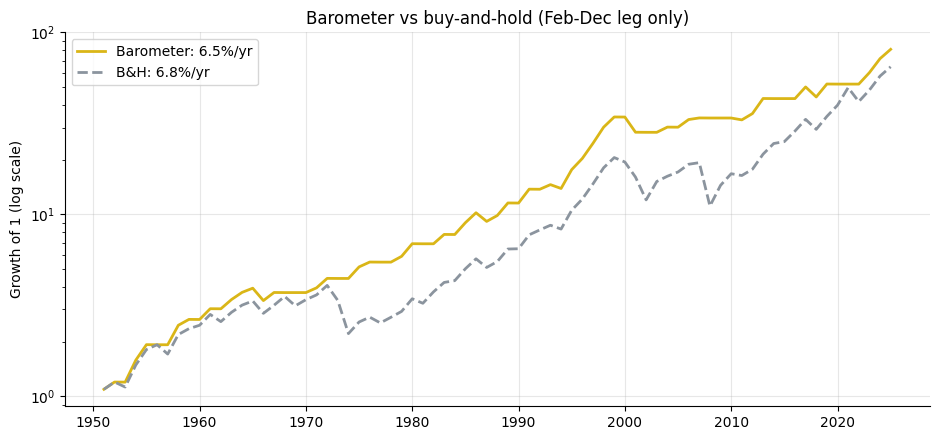

Barometer: 6.47%/yr Sharpe 0.661
Buy-hold:  6.80%/yr Sharpe 0.474
Verdict: the barometer underperforms on mean return (-0.33%/yr) while
missing 18 positive years in the 30 down-January periods.


In [5]:
if HAVE_REAL:
    df = get_real()
    res = st.barometer_strategy(df, cost_bps=10.0)
    strat_r = res['strat_returns']; bah_r = res['bah_returns']
    strat_cum = (1 + strat_r.fillna(0)).cumprod()
    bah_cum = (1 + bah_r.fillna(0)).cumprod()
    strat_m, bah_m = res['strat_mean_ann_pct'], res['bah_mean_ann_pct']
    strat_sr, bah_sr = res['strat_sharpe'], res['bah_sharpe']
else:
    strat_m, bah_m = R['strat_mean'], R['bah_mean']
    strat_sr, bah_sr = R['strat_sharpe'], R['bah_sharpe']
    strat_cum = bah_cum = None
if strat_cum is not None:
    fig, ax = plt.subplots(figsize=(9.5, 4.5))
    ax.semilogy(strat_cum.index, strat_cum, c=AMBER, lw=2, label=f'Barometer: {strat_m:.1f}%/yr')
    ax.semilogy(bah_cum.index, bah_cum, c=GREY, lw=2, ls='--', label=f'B&H: {bah_m:.1f}%/yr')
    ax.set_ylabel('Growth of 1 (log scale)'); ax.legend()
    ax.set_title('Barometer vs buy-and-hold (Feb-Dec leg only)')
    plt.tight_layout(); plt.show()
print(f'Barometer: {strat_m:.2f}%/yr Sharpe {strat_sr:.3f}')
print(f'Buy-hold:  {bah_m:.2f}%/yr Sharpe {bah_sr:.3f}')
print('Verdict: the barometer underperforms on mean return (-0.33%/yr) while')
print('missing 18 positive years in the 30 down-January periods.')

The barometer strategy earns **6.5 %/yr** vs buy-and-hold's **6.8 %/yr**.  Going flat in down-January years sounds cautious, but in 18 of those 30 years, the rest-of-year was still positive.  You missed those gains.

> The barometer is right about big bear years (2000, 2008, 2022 all had down Januaries) but wrong often enough in the other 60 % of down-Januaries to not be worth the trouble.

## 7 Going further

- **The base-rate trap applies to many calendar claims.** If the Sell-in-May effect ([Study 55 -- Summer-Lull](../../55-summer-lull/)) or any other seasonal wins 'most of the time', always ask: does it beat the unconditional positive rate?
- **The 'other January effect'.** Cooper, McConnell & Ovtchinnikov (2006) showed the *level* of the January return predicts the *size* of the full-year return -- a different and arguably stronger claim than the sign prediction.  Worth testing.
- **International data.**  Does the barometer work outside the US?  If it is a genuine seasonal it should appear in other markets too.

*Think the barometer is real?  Fork this, add international data or a full-year return regression on January level, and show it beats the base rate and survives post-1985.  That's the bar.*